In [1]:
from pathlib import Path
import json
import re
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


DATA_DIR = Path.cwd() / "Data"

SEGMENTED_DIR = Path.cwd() / "Dataset_Segmented"
SEGMENTED_DIR.mkdir(exist_ok=True)

NORMALIZED_DIR = Path.cwd() / "Dataset_Normalzied"
NORMALIZED_DIR.mkdir(exist_ok=True)

NORMALIZED_EXPORT_DIR = NORMALIZED_DIR

SIGNAL_COLS = ["ACXXX_SN1 [g]", "ACXXX_SN2 [g]"]
TACHO_COL = "Tacho_Ch8 [Hz]"

COMPONENT_KEYS = ["amplitude_db", "phase_sin", "phase_cos"]

SEGMENTS_PER_SAMPLE = 7

TRAIN_RATIO = 0.8
RANDOM_SEED = 42

MAX_HIST_VALUES = 2_000_000

ANGLE_DIVISIONS = 17

# Promienie w milimetrach
R_zew = 100.0
R_sr = 90.0

# 1. Wyliczenie surowych wartości niewyważenia w g*mm
LOCATION_TO_IMBALANCE_RAW = {
    "baseline": 0.0,

    "sr": 1.79 * R_sr,
    "srodek": 1.79 * R_sr,
    "środek": 1.79 * R_sr,

    "zew": 1.79 * R_zew,
    "zewnatrz": 1.79 * R_zew,
    "zewnątrz": 1.79 * R_zew,

    "zew2": 2.61 * R_zew,

    "zew_sr": (1.79 * R_zew) + (1.75 * R_sr),
    "zew_srodek": (1.79 * R_zew) + (1.75 * R_sr),
    "zew_środek": (1.79 * R_zew) + (1.75 * R_sr),
}

MAX_IMBALANCE = max(LOCATION_TO_IMBALANCE_RAW.values())
LOCATION_TO_IMBALANCE = {
    key: value / MAX_IMBALANCE for key, value in LOCATION_TO_IMBALANCE_RAW.items()
}

CLEAR_EXPORTED_DATASETS = True


In [2]:
def natural_key(path):
    return [int(x) if x.isdigit() else x.lower() for x in re.split(r"(\d+)", path.name)]


def normalize_location_text(text):
    if text is None:
        return None

    text = str(text).lower()
    text = text.replace(" ", "_")
    text = text.replace("-", "_")
    return text


def load_payload(path):
    return np.load(path, allow_pickle=True).item()


def has_tachometer(payload):
    return TACHO_COL in payload["channels"]


def component_name(signal_col, quantity):
    return f"{signal_col} | {quantity}"


def get_location_from_payload(payload):
    metadata = payload.get("metadata", {})
    return normalize_location_text(metadata.get("location", None))


def get_imbalance_from_location(location):
    location = normalize_location_text(location)

    if location not in LOCATION_TO_IMBALANCE:
        raise ValueError(f"Unknown location/imbalance label: {location!r}")

    return float(LOCATION_TO_IMBALANCE[location])


def payload_has_required_sincos_phase(payload, required_channels):
    for channel_name in required_channels:
        if channel_name not in payload["channels"]:
            return False

        channel = payload["channels"][channel_name]
        required_keys = {"amplitude_db", "phase_sin", "phase_cos"}

        if not required_keys.issubset(channel.keys()):
            return False

    return True


def payload_phase_status(payload):
    has_phase_rad = False
    has_sincos = True

    for channel in payload["channels"].values():
        if "phase_rad" in channel:
            has_phase_rad = True

        if "phase_sin" not in channel or "phase_cos" not in channel:
            has_sincos = False

    if has_sincos:
        return "new_sin_cos"

    if has_phase_rad:
        return "legacy_phase_rad"

    return "unknown_phase_format"


def angle_label_to_target(angle_label):
    if angle_label is None:
        raise ValueError("angle_label cannot be None")

    angle_label = int(angle_label)
    angle_rad = 2 * np.pi * angle_label / ANGLE_DIVISIONS

    return {
        "angle_label": angle_label,
        "angle_rad": float(angle_rad),
        "angle_sin": float(np.sin(angle_rad)),
        "angle_cos": float(np.cos(angle_rad)),
        "angle_sin_cos": np.array(
            [np.sin(angle_rad), np.cos(angle_rad)],
            dtype=np.float32,
        ),
    }


In [3]:
def payload_to_array(payload, dataset_kind):
    channels = payload["channels"]

    if dataset_kind == "non_tacho":
        signal_order = SIGNAL_COLS.copy()
    elif dataset_kind == "tacho":
        if TACHO_COL not in channels:
            raise KeyError("Tachometer channel requested but not present in payload.")
        signal_order = SIGNAL_COLS.copy() + [TACHO_COL]
    else:
        raise ValueError(f"Unknown dataset_kind: {dataset_kind!r}")

    arrays = []
    component_names = []

    for signal_col in signal_order:
        if signal_col not in channels:
            raise KeyError(f"Channel {signal_col!r} not found in payload.")

        channel = channels[signal_col]

        for component_key in COMPONENT_KEYS:
            if component_key not in channel:
                raise KeyError(
                    f"Component {component_key!r} not found for channel {signal_col!r}. "
                    f"Available: {list(channel.keys())}."
                )

            arrays.append(channel[component_key].astype(np.float32))
            component_names.append(component_name(signal_col, component_key))

    X = np.stack(arrays, axis=0)

    return X, component_names


def make_base_metadata(payload, path, dataset_kind):
    metadata = dict(payload.get("metadata", {}))

    location = get_location_from_payload(payload)
    imbalance_value = get_imbalance_from_location(location)

    if metadata.get("angle", None) is None:
        raise ValueError(f"Missing angle in metadata for {path.name}")

    angle_target = angle_label_to_target(metadata["angle"])

    source_has_tacho = has_tachometer(payload)

    metadata.update({
        "source_npy": path.name,
        "source_stem": path.stem,
        "location": location,
        "imbalance_value": imbalance_value,
        "source_has_tacho": source_has_tacho,
        "dataset_kind": dataset_kind,
        "tacho_included_in_X": dataset_kind == "tacho",
        "fs": payload.get("fs", None),
        "nperseg": payload.get("nperseg", None),
        "f_min_hz": payload.get("f_min_hz", None),
        "f_max_hz": payload.get("f_max_hz", None),
        "angle_divisions": ANGLE_DIVISIONS,
        "angle_rad": angle_target["angle_rad"],
        "angle_sin": angle_target["angle_sin"],
        "angle_cos": angle_target["angle_cos"],
        "phase_representation_loaded": "sin_cos",
    })

    return metadata, angle_target

def get_actual_labels_from_signal(X_segment, component_names, good_sensor="ACXXX_SN1 [g]"):
    amp_idx = component_names.index(f"{good_sensor} | amplitude_db")
    sin_idx = component_names.index(f"{good_sensor} | phase_sin")
    cos_idx = component_names.index(f"{good_sensor} | phase_cos")
    amp_db = X_segment[amp_idx]
    p_sin = X_segment[sin_idx]
    p_cos = X_segment[cos_idx]

    amp_linear = 10 ** (amp_db / 20.0)
    Z = amp_linear * (p_cos + 1j * p_sin)
    amp_mean_time = np.mean(np.abs(Z), axis=1)
    max_idx = np.argmax(amp_mean_time)
    start_idx = max(0, max_idx - 1)
    end_idx = min(Z.shape[0], max_idx + 2)
    Z_window = Z[start_idx:end_idx, :]
    z_korekta = np.mean(np.sum(Z_window, axis=0))
    actual_amp = float(np.abs(z_korekta))
    actual_phase_rad = float(np.angle(z_korekta))

    return actual_amp, actual_phase_rad

def segment_payload(path, dataset_kind, segments_per_sample=SEGMENTS_PER_SAMPLE):
    payload = load_payload(path)

    if dataset_kind == "tacho" and not has_tachometer(payload):
        return [], None, None

    X, component_names = payload_to_array(payload, dataset_kind=dataset_kind)

    frequency_hz = payload["frequency_hz"].astype(np.float32)
    time_s = payload["time_s"].astype(np.float32)

    time_bins = X.shape[-1]

    if time_bins != len(time_s):
        raise ValueError(
            f"Time axis mismatch in {path.name}: X has {time_bins} time bins, "
            f"but time_s has length {len(time_s)}."
        )

    if time_bins % segments_per_sample != 0:
        raise ValueError(
            f"Cannot split {path.name}: time axis length {time_bins} is not divisible "
            f"by {segments_per_sample}."
        )

    segment_len = time_bins // segments_per_sample

    base_metadata, angle_target = make_base_metadata(
        payload,
        path,
        dataset_kind,
    )

    datapoints = []

    for segment_idx in range(segments_per_sample):
        start = segment_idx * segment_len
        stop = start + segment_len

        segment_metadata = dict(base_metadata)
        segment_metadata.update({
            "segment_idx": segment_idx,
            "segment_start_bin": start,
            "segment_stop_bin": stop,
            "segment_time_len": segment_len,
            "segment_start_time_s": float(time_s[start]),
            "segment_end_time_s": float(time_s[stop - 1]),
        })

        X_seg = X[:, :, start:stop].astype(np.float32)

        actual_amp, actual_phase_rad = get_actual_labels_from_signal(
            X_seg,
            component_names,
            good_sensor="ACXXX_SN1 [g]"
        )

        dp = {
            "X": X_seg,
            "time_s": time_s[start:stop].astype(np.float32),
            "y_imbalance_value": float(base_metadata["imbalance_value"]),
            "y_angle_label": int(angle_target["angle_label"]),
            "y_angle_rad": float(angle_target["angle_rad"]),
            "y_angle_sin_cos": angle_target["angle_sin_cos"],
            "y_actual_amp": actual_amp,
            "y_actual_phase_rad": actual_phase_rad,
            "y_actual_phase_sin_cos": np.array([np.sin(actual_phase_rad), np.cos(actual_phase_rad)], dtype=np.float32),

            "metadata": segment_metadata,
            "component_names": component_names,
        }

        datapoints.append(dp)

    return datapoints, frequency_hz, component_names


In [4]:
all_npy_files = sorted(DATA_DIR.glob("*.npy"), key=natural_key)

print(f"Found {len(all_npy_files)} .npy files in {DATA_DIR}")

if not all_npy_files:
    raise FileNotFoundError(f"No .npy files found in {DATA_DIR}")

phase_rows = []
invalid_files = []

for path in all_npy_files:
    payload = load_payload(path)

    required_channels = SIGNAL_COLS.copy()

    # For validation of tacho files, tacho itself is checked later only when used.
    is_valid_for_non_tacho = payload_has_required_sincos_phase(payload, required_channels=SIGNAL_COLS)

    metadata = payload.get("metadata", {})
    location = normalize_location_text(metadata.get("location", None))
    angle = metadata.get("angle", None)

    location_known = location in LOCATION_TO_IMBALANCE
    angle_known = angle is not None

    phase_rows.append({
        "file": path.name,
        "phase_status": payload_phase_status(payload),
        "valid_sincos": is_valid_for_non_tacho,
        "angle": angle,
        "location": location,
        "location_known": location_known,
        "angle_known": angle_known,
        "tacho": has_tachometer(payload),
    })

    if not is_valid_for_non_tacho or not location_known or not angle_known:
        invalid_files.append(path)

diagnostic = pd.DataFrame(phase_rows)

display(diagnostic)

if invalid_files:
    print("Invalid files:")
    for path in invalid_files:
        print(" ", path.name)

    raise ValueError(
        "Some .npy files cannot be used. Rerun the preparation notebook with CLEAR_DATA_DIR=True "
        "or check unexpected filename/location labels."
    )

npy_files = all_npy_files

print("All .npy files are valid and will be used.")

print("Angle counts:")
display(diagnostic["angle"].value_counts(dropna=False).sort_index())

print("Location counts:")
display(diagnostic["location"].value_counts(dropna=False).sort_index())

print("Tacho availability:")
display(diagnostic["tacho"].value_counts(dropna=False))


Found 322 .npy files in D:\Projects\GitHub\Wywazanie\Pipeline\Data


,file,phase_status,valid_sincos,angle,location,location_known,angle_known,tacho
0,v01_14_a0_baseline_spectrogram.npy,new_sin_cos,True,0,baseline,True,True,True
1,v01_14_a1_sr_spectrogram.npy,new_sin_cos,True,1,sr,True,True,False
2,v01_14_a1_zew2_spectrogram.npy,new_sin_cos,True,1,zew2,True,True,False
3,v01_14_a1_zew_spectrogram.npy,new_sin_cos,True,1,zew,True,True,True
4,v01_14_a3_sr_spectrogram.npy,new_sin_cos,True,3,sr,True,True,False
...,...,...,...,...,...,...,...,...
317,v14_14_a13_zew2_spectrogram.npy,new_sin_cos,True,13,zew2,True,True,False
318,v14_14_a13_zew_spectrogram.npy,new_sin_cos,True,13,zew,True,True,True
319,v14_14_a15_sr_spectrogram.npy,new_sin_cos,True,15,sr,True,True,False
320,v14_14_a15_zew2_spectrogram.npy,new_sin_cos,True,15,zew2,True,True,False


All .npy files are valid and will be used.
Angle counts:


angle
0     14
1     42
3     42
5     42
7     42
11    56
13    42
15    42
Name: count, dtype: int64

Location counts:


location
baseline    14
sr          98
zew         98
zew2        98
zew_sr      14
Name: count, dtype: int64

Tacho availability:


tacho
False    196
True     126
Name: count, dtype: int64

In [5]:
dataset_tacho = []
dataset_non_tacho = []

frequency_hz_common = None

component_names_tacho = None
component_names_non_tacho = None

source_files_with_tacho = []
source_files_without_tacho = []

for path in npy_files:
    payload = load_payload(path)

    if has_tachometer(payload):
        source_files_with_tacho.append(path.name)
    else:
        source_files_without_tacho.append(path.name)

    non_tacho_datapoints, frequency_hz, component_names = segment_payload(
        path,
        dataset_kind="non_tacho",
    )

    dataset_non_tacho.extend(non_tacho_datapoints)
    component_names_non_tacho = component_names

    if frequency_hz_common is None:
        frequency_hz_common = frequency_hz
    else:
        if not np.allclose(frequency_hz_common, frequency_hz):
            raise ValueError(f"Frequency axis differs in {path.name}")

    if has_tachometer(payload):
        # Validate tacho phase keys only for files that actually contain tacho.
        if not payload_has_required_sincos_phase(
            payload,
            required_channels=SIGNAL_COLS + [TACHO_COL],
        ):
            raise ValueError(f"Tachometer file has invalid phase representation: {path.name}")

        tacho_datapoints, frequency_hz, component_names = segment_payload(
            path,
            dataset_kind="tacho",
        )

        dataset_tacho.extend(tacho_datapoints)
        component_names_tacho = component_names

        if not np.allclose(frequency_hz_common, frequency_hz):
            raise ValueError(f"Frequency axis differs in {path.name}")

print(f"Source files with tachometer:    {len(source_files_with_tacho)}")
print(f"Source files without tachometer: {len(source_files_without_tacho)}")
print()
print(f"Tachometer dataset datapoints:     {len(dataset_tacho)}")
print(f"Non-tachometer dataset datapoints: {len(dataset_non_tacho)}")
print()
print(f"Frequency bins: {len(frequency_hz_common)}")

if dataset_tacho:
    print("Tachometer dataset X shape:", dataset_tacho[0]["X"].shape)
    print("Tachometer components:", dataset_tacho[0]["component_names"])

if dataset_non_tacho:
    print("Non-tachometer dataset X shape:", dataset_non_tacho[0]["X"].shape)
    print("Non-tachometer components:", dataset_non_tacho[0]["component_names"])


Source files with tachometer:    126
Source files without tachometer: 196

Tachometer dataset datapoints:     882
Non-tachometer dataset datapoints: 2254

Frequency bins: 5000
Tachometer dataset X shape: (9, 5000, 3)
Tachometer components: ['ACXXX_SN1 [g] | amplitude_db', 'ACXXX_SN1 [g] | phase_sin', 'ACXXX_SN1 [g] | phase_cos', 'ACXXX_SN2 [g] | amplitude_db', 'ACXXX_SN2 [g] | phase_sin', 'ACXXX_SN2 [g] | phase_cos', 'Tacho_Ch8 [Hz] | amplitude_db', 'Tacho_Ch8 [Hz] | phase_sin', 'Tacho_Ch8 [Hz] | phase_cos']
Non-tachometer dataset X shape: (6, 5000, 3)
Non-tachometer components: ['ACXXX_SN1 [g] | amplitude_db', 'ACXXX_SN1 [g] | phase_sin', 'ACXXX_SN1 [g] | phase_cos', 'ACXXX_SN2 [g] | amplitude_db', 'ACXXX_SN2 [g] | phase_sin', 'ACXXX_SN2 [g] | phase_cos']


In [6]:
def dataset_summary(name, dataset):
    print("=" * 80)
    print(name)
    print("=" * 80)

    if not dataset:
        print("Empty dataset.")
        return

    source_count = len(set(dp["metadata"]["source_npy"] for dp in dataset))

    print(f"Datapoints: {len(dataset)}")
    print(f"Source .npy files: {source_count}")
    print(f"X shape example: {dataset[0]['X'].shape}")
    print(f"Components: {dataset[0]['component_names']}")

    print("Angle label counts:")
    display(pd.Series([dp["y_angle_label"] for dp in dataset]).value_counts(dropna=False).sort_index())

    print("Imbalance value counts:")
    display(pd.Series([dp["y_imbalance_value"] for dp in dataset]).value_counts(dropna=False).sort_index())


dataset_summary("Tachometer dataset", dataset_tacho)
dataset_summary("Non-tachometer dataset", dataset_non_tacho)


Tachometer dataset
Datapoints: 882
Source .npy files: 126
X shape example: (9, 5000, 3)
Components: ['ACXXX_SN1 [g] | amplitude_db', 'ACXXX_SN1 [g] | phase_sin', 'ACXXX_SN1 [g] | phase_cos', 'ACXXX_SN2 [g] | amplitude_db', 'ACXXX_SN2 [g] | phase_sin', 'ACXXX_SN2 [g] | phase_cos', 'Tacho_Ch8 [Hz] | amplitude_db', 'Tacho_Ch8 [Hz] | phase_sin', 'Tacho_Ch8 [Hz] | phase_cos']
Angle label counts:


0      98
1      98
3      98
5      98
7      98
11    196
13     98
15     98
Name: count, dtype: int64

Imbalance value counts:


0.000000     98
0.531947    686
1.000000     98
Name: count, dtype: int64

Non-tachometer dataset
Datapoints: 2254
Source .npy files: 322
X shape example: (6, 5000, 3)
Components: ['ACXXX_SN1 [g] | amplitude_db', 'ACXXX_SN1 [g] | phase_sin', 'ACXXX_SN1 [g] | phase_cos', 'ACXXX_SN2 [g] | amplitude_db', 'ACXXX_SN2 [g] | phase_sin', 'ACXXX_SN2 [g] | phase_cos']
Angle label counts:


0      98
1     294
3     294
5     294
7     294
11    392
13    294
15    294
Name: count, dtype: int64

Imbalance value counts:


0.000000     98
0.478752    686
0.531947    686
0.775632    686
1.000000     98
Name: count, dtype: int64

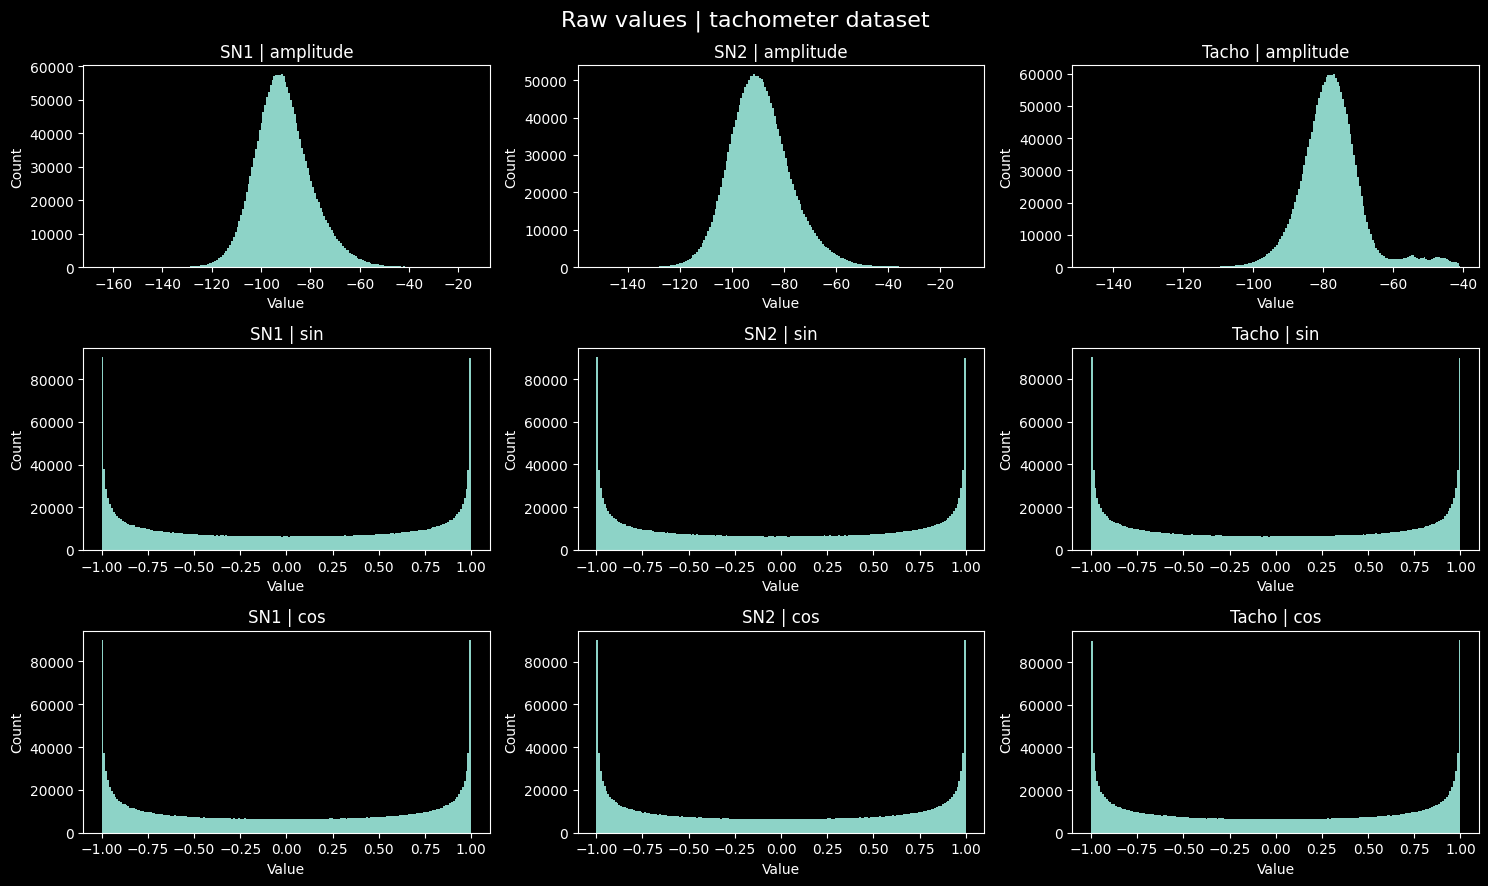

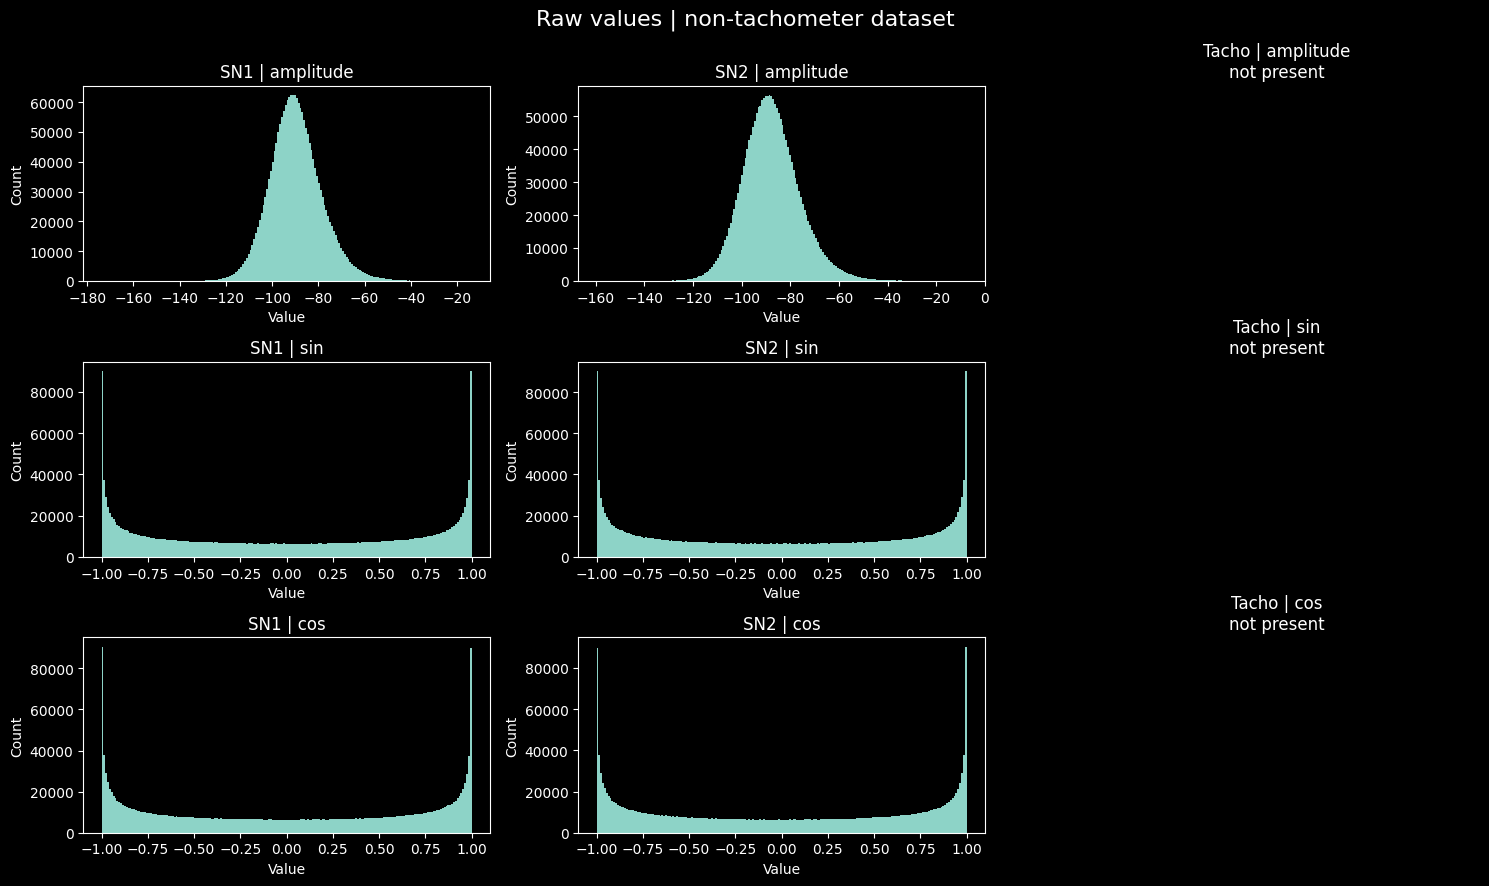

In [7]:
SENSOR_COMPONENT_MAP = {
    "SN1": {
        "amplitude": "ACXXX_SN1 [g] | amplitude_db",
        "sin": "ACXXX_SN1 [g] | phase_sin",
        "cos": "ACXXX_SN1 [g] | phase_cos",
    },
    "SN2": {
        "amplitude": "ACXXX_SN2 [g] | amplitude_db",
        "sin": "ACXXX_SN2 [g] | phase_sin",
        "cos": "ACXXX_SN2 [g] | phase_cos",
    },
    "Tacho": {
        "amplitude": "Tacho_Ch8 [Hz] | amplitude_db",
        "sin": "Tacho_Ch8 [Hz] | phase_sin",
        "cos": "Tacho_Ch8 [Hz] | phase_cos",
    },
}


def sample_values_by_component(dataset, max_values_per_component=MAX_HIST_VALUES, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)

    if not dataset:
        return {}, {}, {}

    component_names = dataset[0]["component_names"]

    values_by_component = {}
    total_by_component = {}
    sampled_by_component = {}

    for component_idx, component in enumerate(component_names):
        total_values = int(sum(dp["X"][component_idx].size for dp in dataset))
        total_by_component[component] = total_values

        if total_values <= max_values_per_component:
            values = np.concatenate([
                dp["X"][component_idx].ravel()
                for dp in dataset
            ]).astype(np.float32)

            values_by_component[component] = values
            sampled_by_component[component] = False
            continue

        values_per_dp = max(1, max_values_per_component // len(dataset))
        sampled = []

        for dp in dataset:
            flat = dp["X"][component_idx].ravel()

            if len(flat) <= values_per_dp:
                sampled.append(flat)
            else:
                idx = rng.choice(len(flat), size=values_per_dp, replace=False)
                sampled.append(flat[idx])

        values_by_component[component] = np.concatenate(sampled).astype(np.float32)
        sampled_by_component[component] = True

    return values_by_component, total_by_component, sampled_by_component


def plot_dataset_amplitude_sincos_grid(dataset, dataset_name, bins=200):
    values_by_component, total_by_component, sampled_by_component = sample_values_by_component(dataset)

    sensors = list(SENSOR_COMPONENT_MAP.keys())
    rows = ["amplitude", "sin", "cos"]

    fig, axes = plt.subplots(
        len(rows),
        len(sensors),
        figsize=(5.0 * len(sensors), 9),
        squeeze=False,
    )

    for col_idx, sensor_name in enumerate(sensors):
        for row_idx, row_name in enumerate(rows):
            ax = axes[row_idx, col_idx]
            component = SENSOR_COMPONENT_MAP[sensor_name][row_name]

            if component not in values_by_component:
                ax.axis("off")
                ax.set_title(f"{sensor_name} | {row_name}\nnot present")
                continue

            values = values_by_component[component]
            ax.hist(values, bins=bins)
            ax.set_title(f"{sensor_name} | {row_name}")
            ax.set_xlabel("Value")
            ax.set_ylabel("Count")

    fig.suptitle(dataset_name, fontsize=16)
    plt.tight_layout()
    plt.show()


plot_dataset_amplitude_sincos_grid(dataset_tacho, "Raw values | tachometer dataset")
plot_dataset_amplitude_sincos_grid(dataset_non_tacho, "Raw values | non-tachometer dataset")


In [8]:
raw_tacho_bundle = {
    "data": dataset_tacho,
    "frequency_hz": frequency_hz_common,
    "component_names": component_names_tacho,
    "location_to_imbalance": LOCATION_TO_IMBALANCE,
    "dataset_kind": "tacho",
    "phase_representation": "sin_cos",
    "angle_divisions": ANGLE_DIVISIONS,
}

raw_non_tacho_bundle = {
    "data": dataset_non_tacho,
    "frequency_hz": frequency_hz_common,
    "component_names": component_names_non_tacho,
    "location_to_imbalance": LOCATION_TO_IMBALANCE,
    "dataset_kind": "non_tacho",
    "phase_representation": "sin_cos",
    "angle_divisions": ANGLE_DIVISIONS,
}

np.save(
    SEGMENTED_DIR / "dataset_tacho_raw_segments.npy",
    raw_tacho_bundle,
    allow_pickle=True,
)

np.save(
    SEGMENTED_DIR / "dataset_non_tacho_raw_segments.npy",
    raw_non_tacho_bundle,
    allow_pickle=True,
)

with open(SEGMENTED_DIR / "location_to_imbalance.json", "w", encoding="utf-8") as f:
    json.dump(LOCATION_TO_IMBALANCE, f, indent=2, ensure_ascii=False)

print(f"Saved raw segmented datasets to: {SEGMENTED_DIR}")


Saved raw segmented datasets to: D:\Projects\GitHub\Wywazanie\Pipeline\Dataset_Segmented


In [9]:
def label_value_for_split(dp, target_name):
    if target_name == "angle":
        return dp["y_angle_label"]

    if target_name in {"imbalance", "mass"}:
        return dp["y_imbalance_value"]

    raise ValueError(f"Unknown target_name: {target_name!r}")


def print_label_distribution(name, dataset, target_name):
    labels = [label_value_for_split(dp, target_name) for dp in dataset]
    print(name)
    display(pd.Series(labels).value_counts(dropna=False).sort_index())


def split_datapoint_stratified(dataset, target_name, train_ratio=TRAIN_RATIO, seed=RANDOM_SEED):
    """
    Stratifies individual datapoints by target.

    This gives good target coverage in both train and test.
    It can place segments from the same source file in both train and test.
    """

    if not dataset:
        return [], []

    rng = np.random.default_rng(seed)

    by_label = {}

    for dp in dataset:
        label = label_value_for_split(dp, target_name)
        by_label.setdefault(label, []).append(dp)

    train = []
    test = []

    for label, items in sorted(by_label.items(), key=lambda item: str(item[0])):
        items = list(items)
        rng.shuffle(items)

        if len(items) == 1:
            train.extend(items)
            continue

        n_train = int(round(len(items) * train_ratio))
        n_train = max(1, min(n_train, len(items) - 1))

        train.extend(items[:n_train])
        test.extend(items[n_train:])

    rng.shuffle(train)
    rng.shuffle(test)

    return train, test


print_label_distribution("Tachometer full dataset | angle", dataset_tacho, "angle")
print_label_distribution("Non-tachometer full dataset | imbalance", dataset_non_tacho, "imbalance")

train_tacho, test_tacho = split_datapoint_stratified(dataset_tacho, target_name="angle")
train_non_tacho, test_non_tacho = split_datapoint_stratified(dataset_non_tacho, target_name="imbalance")

print("Tachometer dataset:")
print(f"  train datapoints: {len(train_tacho)}")
print(f"  test datapoints:  {len(test_tacho)}")
print_label_distribution("  train angle distribution", train_tacho, "angle")
print_label_distribution("  test angle distribution", test_tacho, "angle")

print("Non-tachometer dataset:")
print(f"  train datapoints: {len(train_non_tacho)}")
print(f"  test datapoints:  {len(test_non_tacho)}")
print_label_distribution("  train imbalance distribution", train_non_tacho, "imbalance")
print_label_distribution("  test imbalance distribution", test_non_tacho, "imbalance")


Tachometer full dataset | angle


0      98
1      98
3      98
5      98
7      98
11    196
13     98
15     98
Name: count, dtype: int64

Non-tachometer full dataset | imbalance


0.000000     98
0.478752    686
0.531947    686
0.775632    686
1.000000     98
Name: count, dtype: int64

Tachometer dataset:
  train datapoints: 703
  test datapoints:  179
  train angle distribution


...

0     20
1     20
3     20
5     20
7     20
11    39
13    20
15    20
Name: count, dtype: int64

Non-tachometer dataset:
  train datapoints: 1803
  test datapoints:  451
  train imbalance distribution


0.000000     78
0.478752    549
0.531947    549
0.775632    549
1.000000     78
Name: count, dtype: int64

  test imbalance distribution


0.000000     20
0.478752    137
0.531947    137
0.775632    137
1.000000     20
Name: count, dtype: int64

In [10]:
def copy_datapoint_with_new_X(dp, X_new, stage):
    new_dp = {
        "X": X_new.astype(np.float32),
        "time_s": dp["time_s"].copy(),
        "y_imbalance_value": dp["y_imbalance_value"],
        "y_angle_label": dp["y_angle_label"],
        "y_angle_rad": dp["y_angle_rad"],
        "y_angle_sin_cos": dp["y_angle_sin_cos"].copy(),
        "y_actual_amp": dp["y_actual_amp"],
        "y_actual_phase_rad": dp["y_actual_phase_rad"],
        "y_actual_phase_sin_cos": dp["y_actual_phase_sin_cos"].copy(),
        "metadata": dict(dp["metadata"]),
        "component_names": list(dp["component_names"]),
    }

    new_dp["metadata"]["processing_stage"] = stage

    return new_dp


def is_normalized_component(component_name):
    """
    Only vibration sensor amplitudes are normalized.

    Normalized:
    - ACXXX_SN1 [g] | amplitude_db
    - ACXXX_SN2 [g] | amplitude_db

    Not normalized:
    - all phase_sin
    - all phase_cos
    - all tachometer components
    """

    return (
        component_name.startswith("ACXXX_SN")
        and component_name.endswith("| amplitude_db")
    )


def normalized_component_indices(component_names):
    return [
        idx
        for idx, name in enumerate(component_names)
        if is_normalized_component(name)
    ]


def unchanged_component_indices(component_names):
    return [
        idx
        for idx, name in enumerate(component_names)
        if not is_normalized_component(name)
    ]


def compute_standardization_stats(dataset):
    if not dataset:
        return None

    component_names = list(dataset[0]["component_names"])
    norm_indices = normalized_component_indices(component_names)
    unchanged_indices = unchanged_component_indices(component_names)

    if not norm_indices:
        raise ValueError("No components selected for normalization.")

    n_norm = len(norm_indices)

    sums = np.zeros(n_norm, dtype=np.float64)
    sums_sq = np.zeros(n_norm, dtype=np.float64)
    counts = np.zeros(n_norm, dtype=np.float64)

    for dp in dataset:
        X = dp["X"].astype(np.float64)

        if list(dp["component_names"]) != component_names:
            raise ValueError("Inconsistent component names inside dataset.")

        X_norm_part = X[norm_indices]

        sums += X_norm_part.sum(axis=(1, 2))
        sums_sq += (X_norm_part ** 2).sum(axis=(1, 2))
        counts += X_norm_part.shape[1] * X_norm_part.shape[2]

    mean = sums / counts
    variance = sums_sq / counts - mean ** 2
    variance = np.maximum(variance, 1e-12)
    std = np.sqrt(variance)

    stats = {
        "mode": "sensor_amplitude_standardization_only",
        "fitted_on": "raw_train_split",
        "normalized_component_indices": norm_indices,
        "normalized_component_names": [component_names[i] for i in norm_indices],
        "unchanged_component_indices": unchanged_indices,
        "unchanged_component_names": [component_names[i] for i in unchanged_indices],
        "all_component_names": component_names,
        "mean": mean.astype(np.float32),
        "std": std.astype(np.float32),
    }

    return stats


def standardize_dataset(dataset, stats):
    if not dataset:
        return []

    if stats is None:
        raise ValueError("Cannot standardize non-empty dataset with stats=None.")

    norm_indices = stats["normalized_component_indices"]
    mean = stats["mean"].astype(np.float32)
    std = stats["std"].astype(np.float32)

    standardized = []

    for dp in dataset:
        X = dp["X"].copy().astype(np.float32)

        if list(dp["component_names"]) != list(stats["all_component_names"]):
            raise ValueError("Component names do not match fitted normalization statistics.")

        for local_idx, component_idx in enumerate(norm_indices):
            X[component_idx] = (X[component_idx] - mean[local_idx]) / std[local_idx]

        standardized.append(copy_datapoint_with_new_X(dp, X, stage="amplitude_standardized_sincos_unchanged"))

    return standardized


stats_tacho = compute_standardization_stats(train_tacho)
stats_non_tacho = compute_standardization_stats(train_non_tacho)

norm_train_tacho = standardize_dataset(train_tacho, stats_tacho)
norm_test_tacho = standardize_dataset(test_tacho, stats_tacho) if test_tacho else []

norm_train_non_tacho = standardize_dataset(train_non_tacho, stats_non_tacho)
norm_test_non_tacho = standardize_dataset(test_non_tacho, stats_non_tacho) if test_non_tacho else []

print("Stats for tachometer dataset:")
print("Normalized:", stats_tacho["normalized_component_names"])
print("Unchanged:", stats_tacho["unchanged_component_names"])

print()
print("Stats for non-tachometer dataset:")
print("Normalized:", stats_non_tacho["normalized_component_names"])
print("Unchanged:", stats_non_tacho["unchanged_component_names"])


Stats for tachometer dataset:
Normalized: ['ACXXX_SN1 [g] | amplitude_db', 'ACXXX_SN2 [g] | amplitude_db']
Unchanged: ['ACXXX_SN1 [g] | phase_sin', 'ACXXX_SN1 [g] | phase_cos', 'ACXXX_SN2 [g] | phase_sin', 'ACXXX_SN2 [g] | phase_cos', 'Tacho_Ch8 [Hz] | amplitude_db', 'Tacho_Ch8 [Hz] | phase_sin', 'Tacho_Ch8 [Hz] | phase_cos']

Stats for non-tachometer dataset:
Normalized: ['ACXXX_SN1 [g] | amplitude_db', 'ACXXX_SN2 [g] | amplitude_db']
Unchanged: ['ACXXX_SN1 [g] | phase_sin', 'ACXXX_SN1 [g] | phase_cos', 'ACXXX_SN2 [g] | phase_sin', 'ACXXX_SN2 [g] | phase_cos']


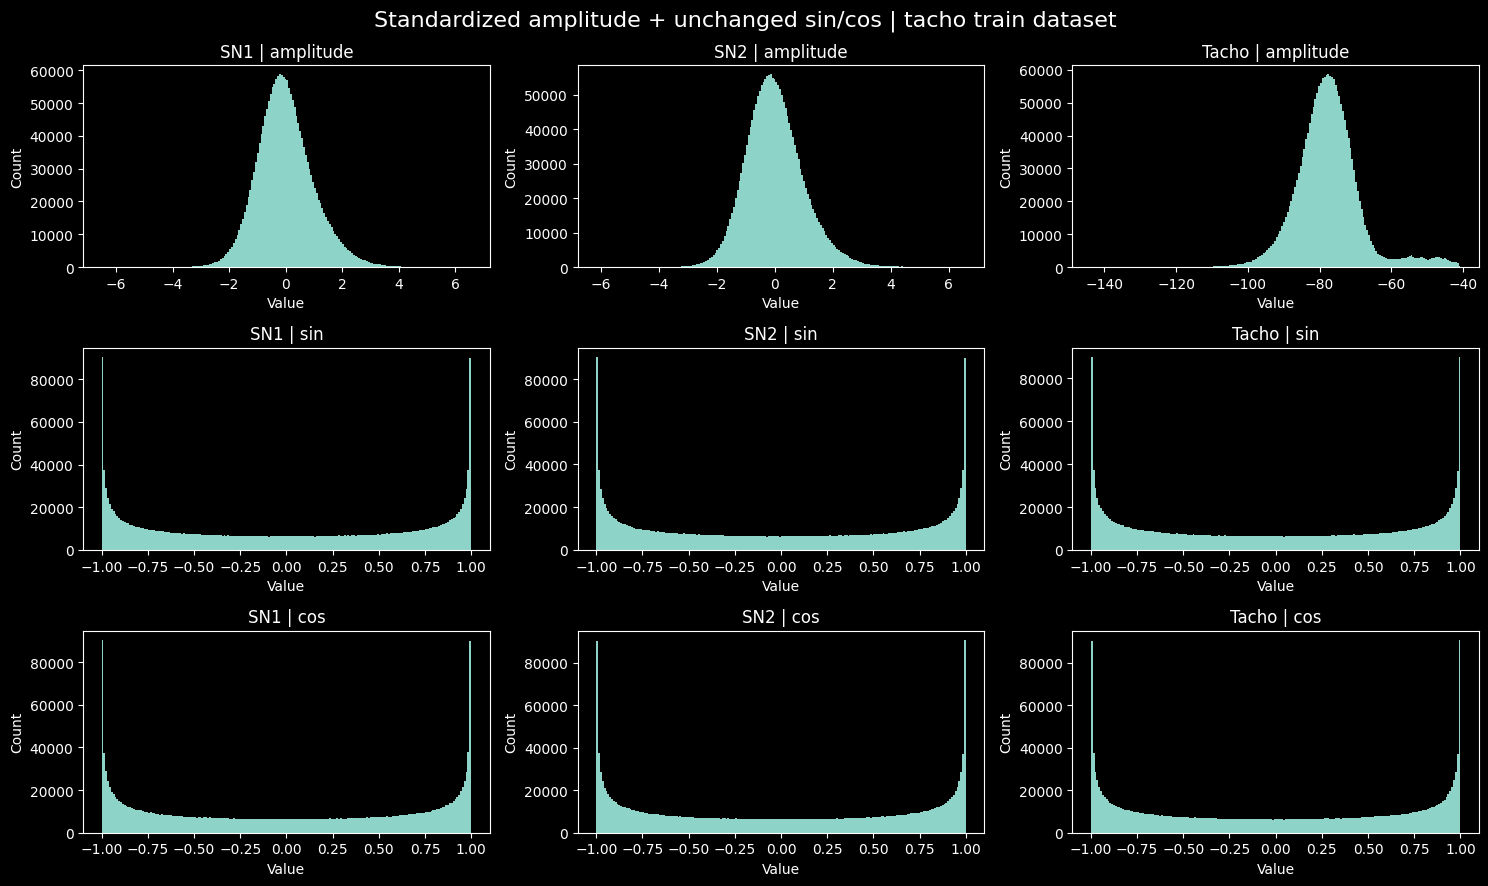

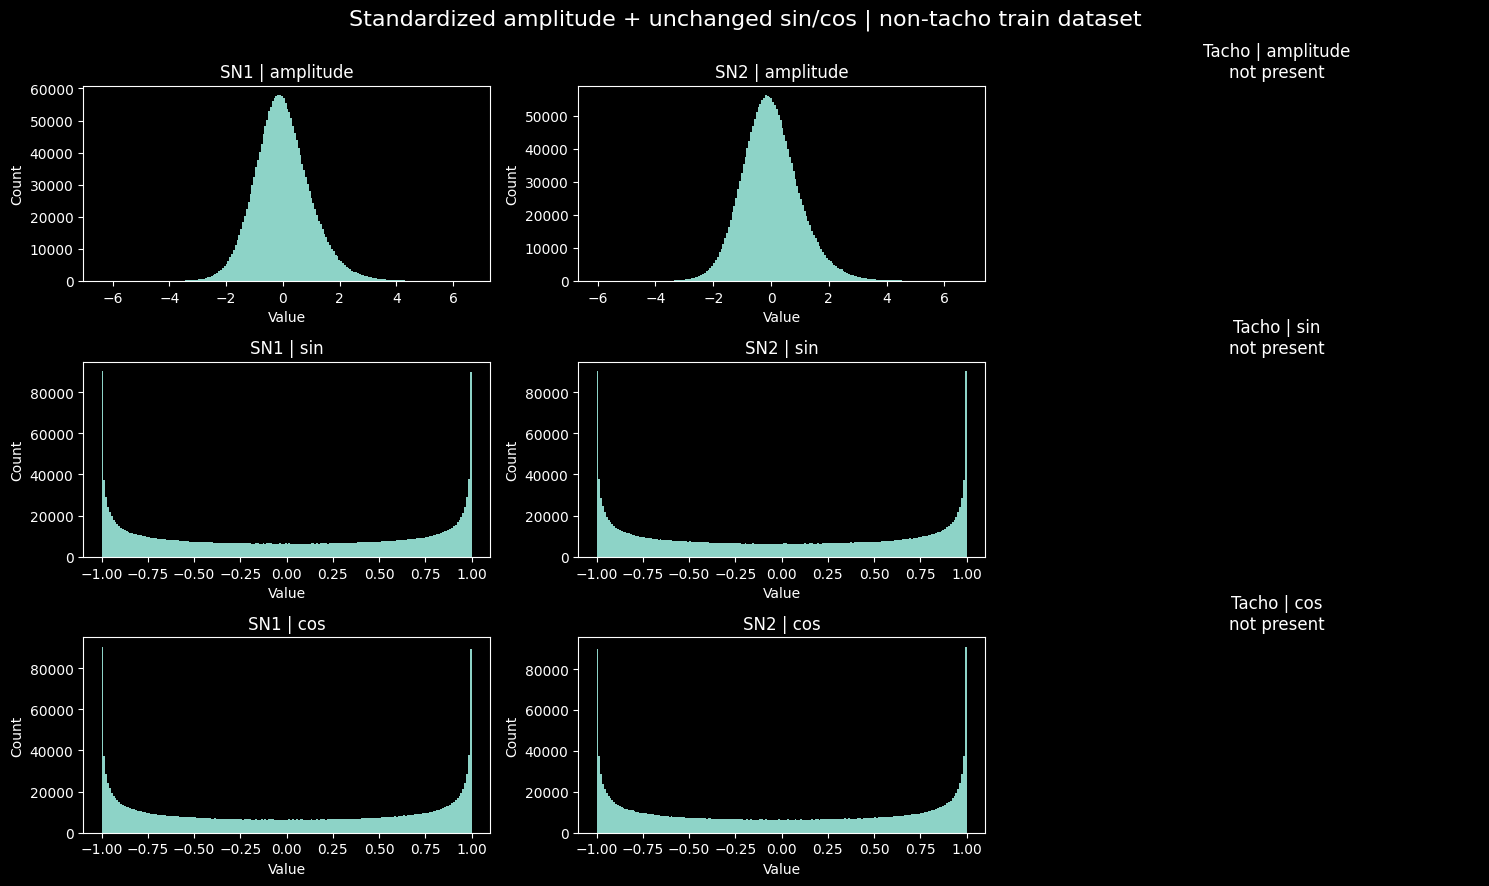

In [11]:
plot_dataset_amplitude_sincos_grid(
    norm_train_tacho,
    "Standardized amplitude + unchanged sin/cos | tacho train dataset",
)

plot_dataset_amplitude_sincos_grid(
    norm_train_non_tacho,
    "Standardized amplitude + unchanged sin/cos | non-tacho train dataset",
)


Amplitude color limits: (-7.3895344734191895, 6.828067779541016)


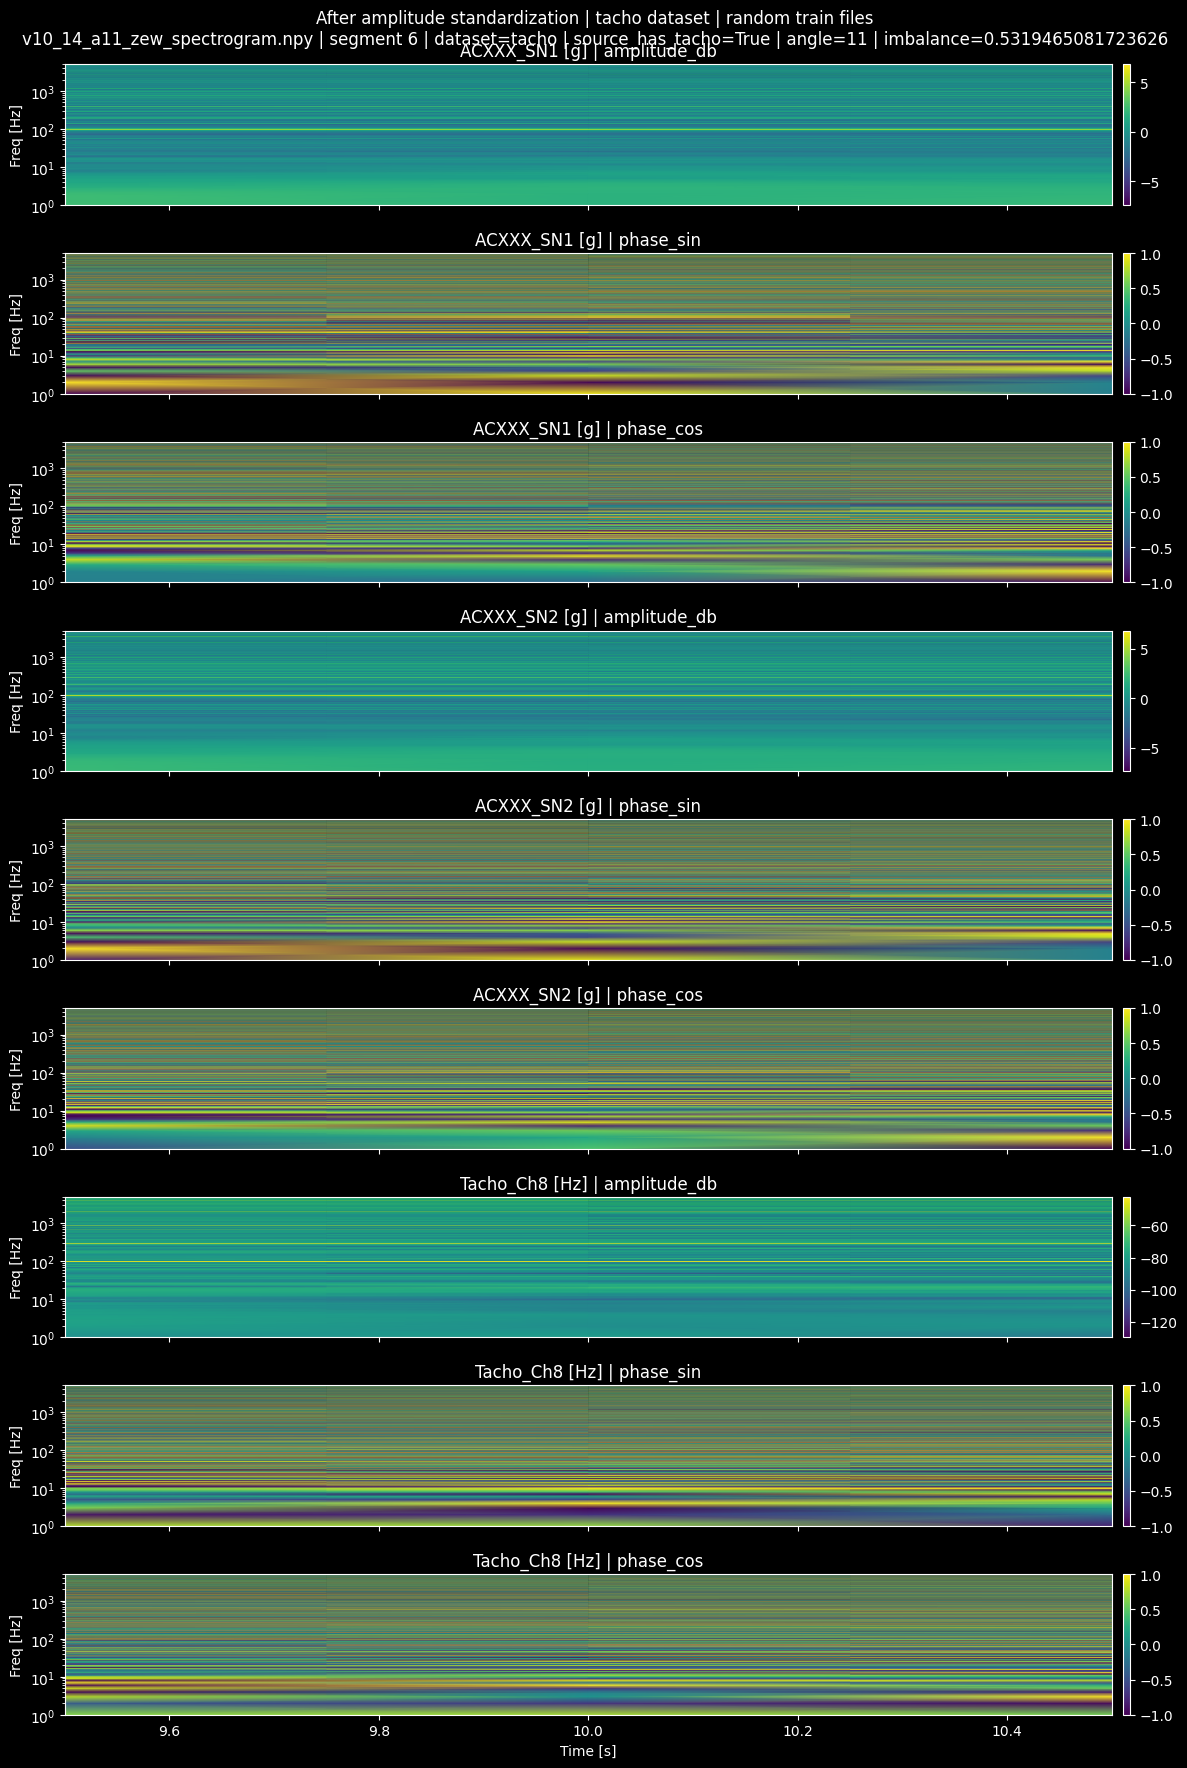

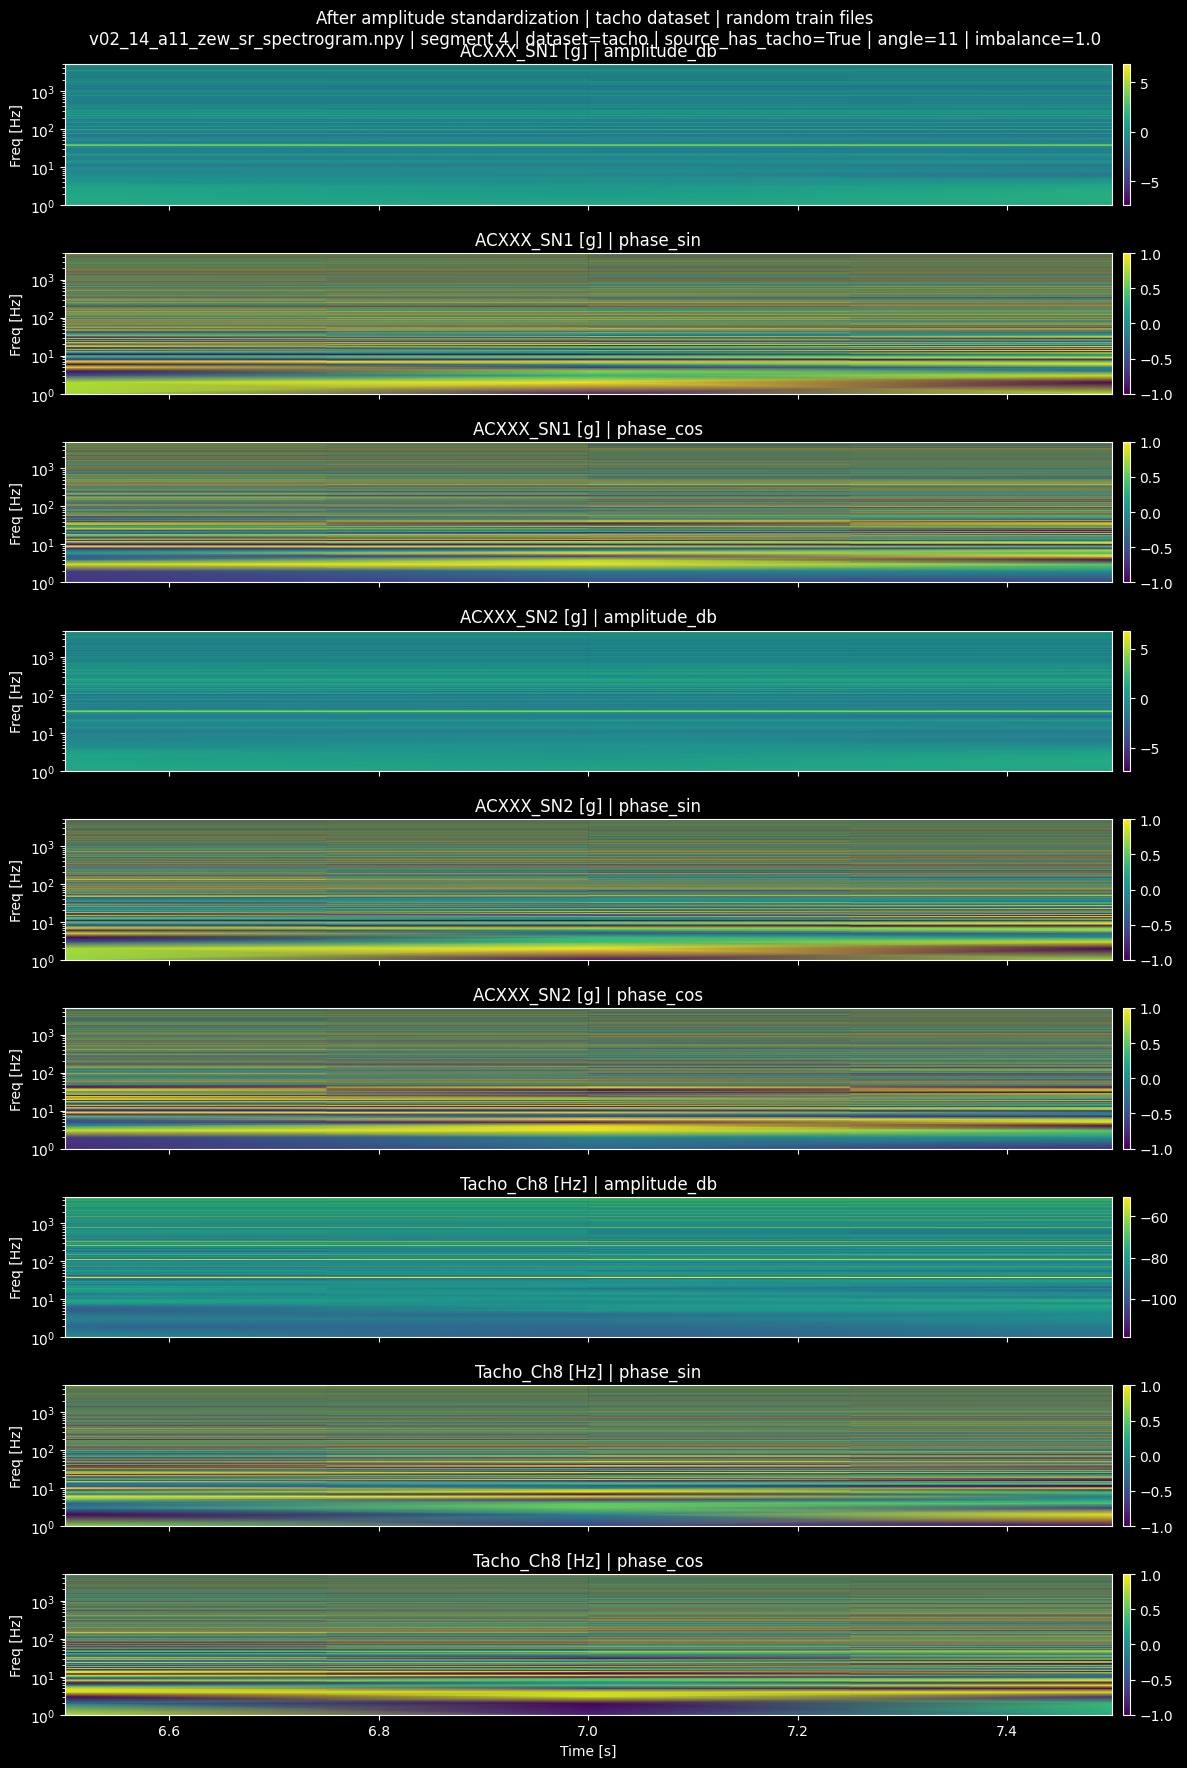

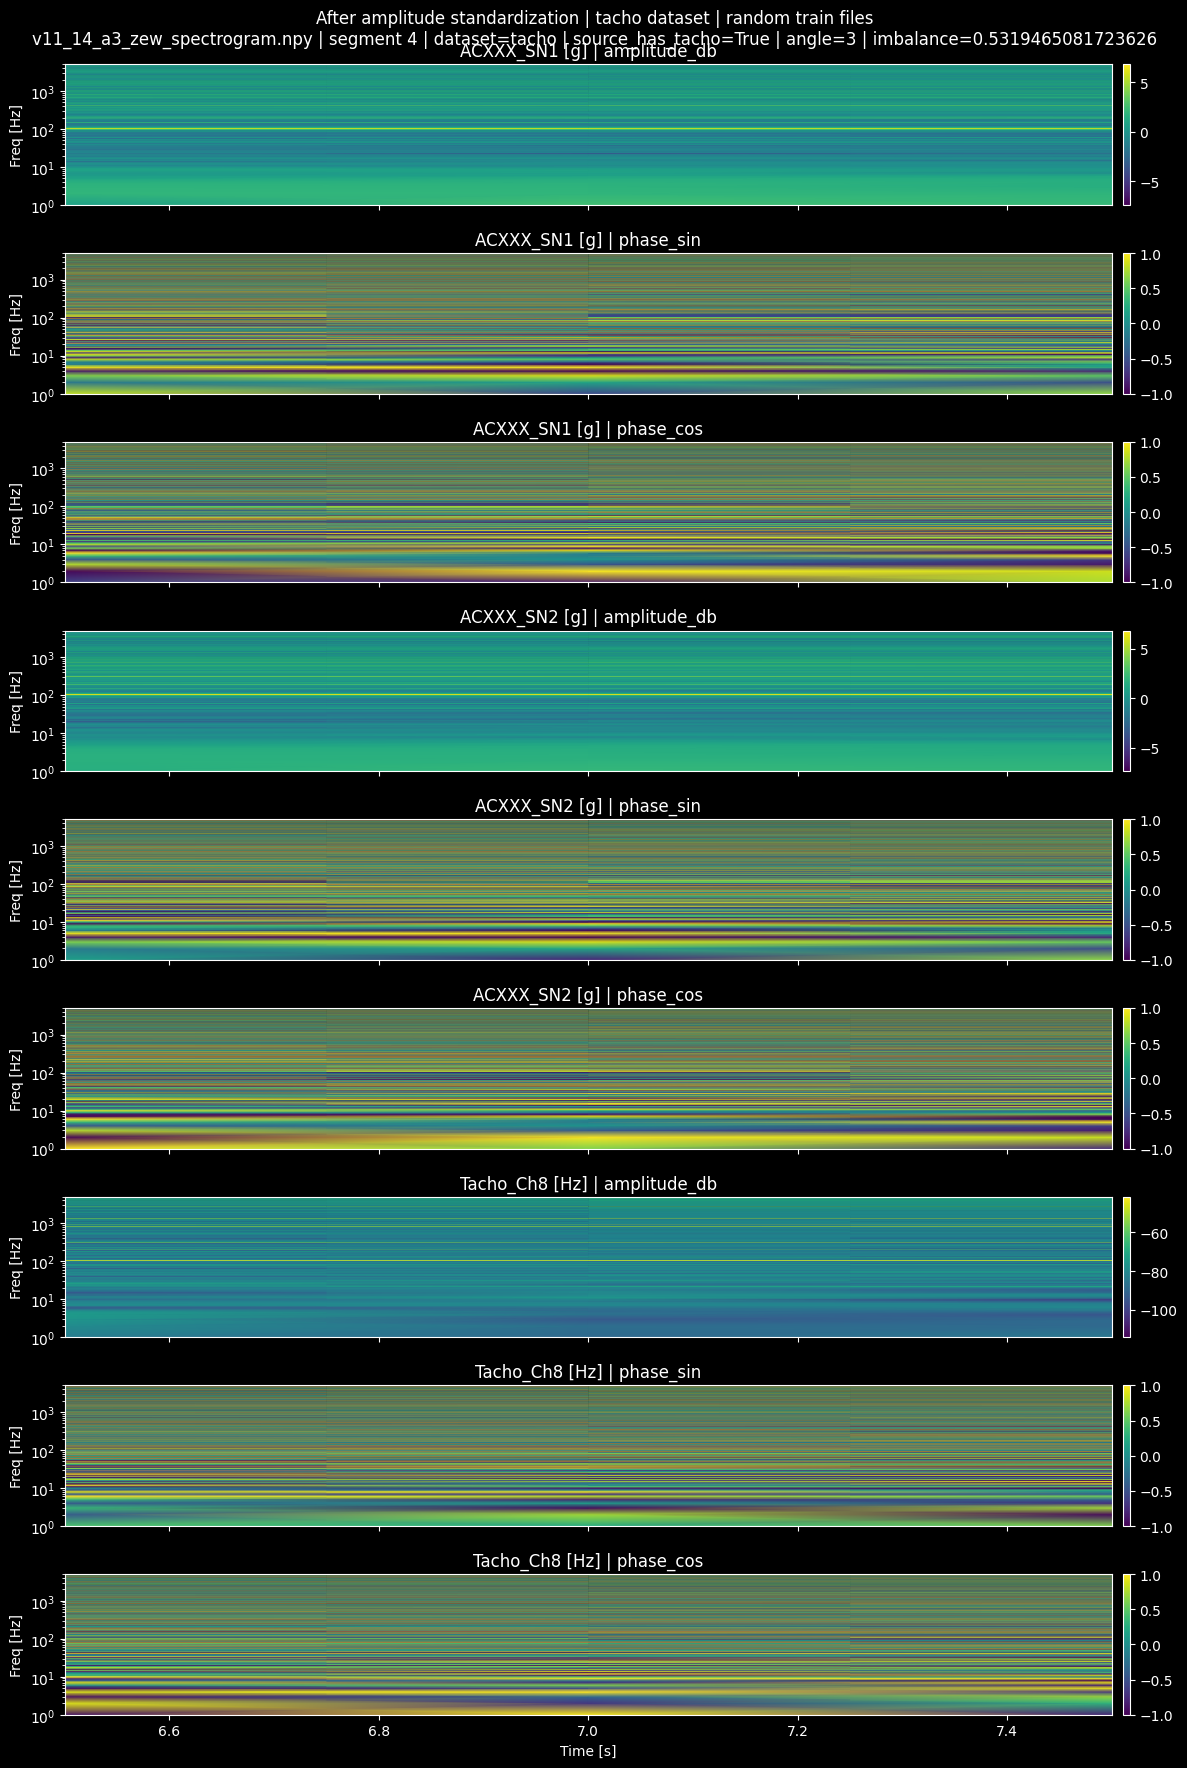

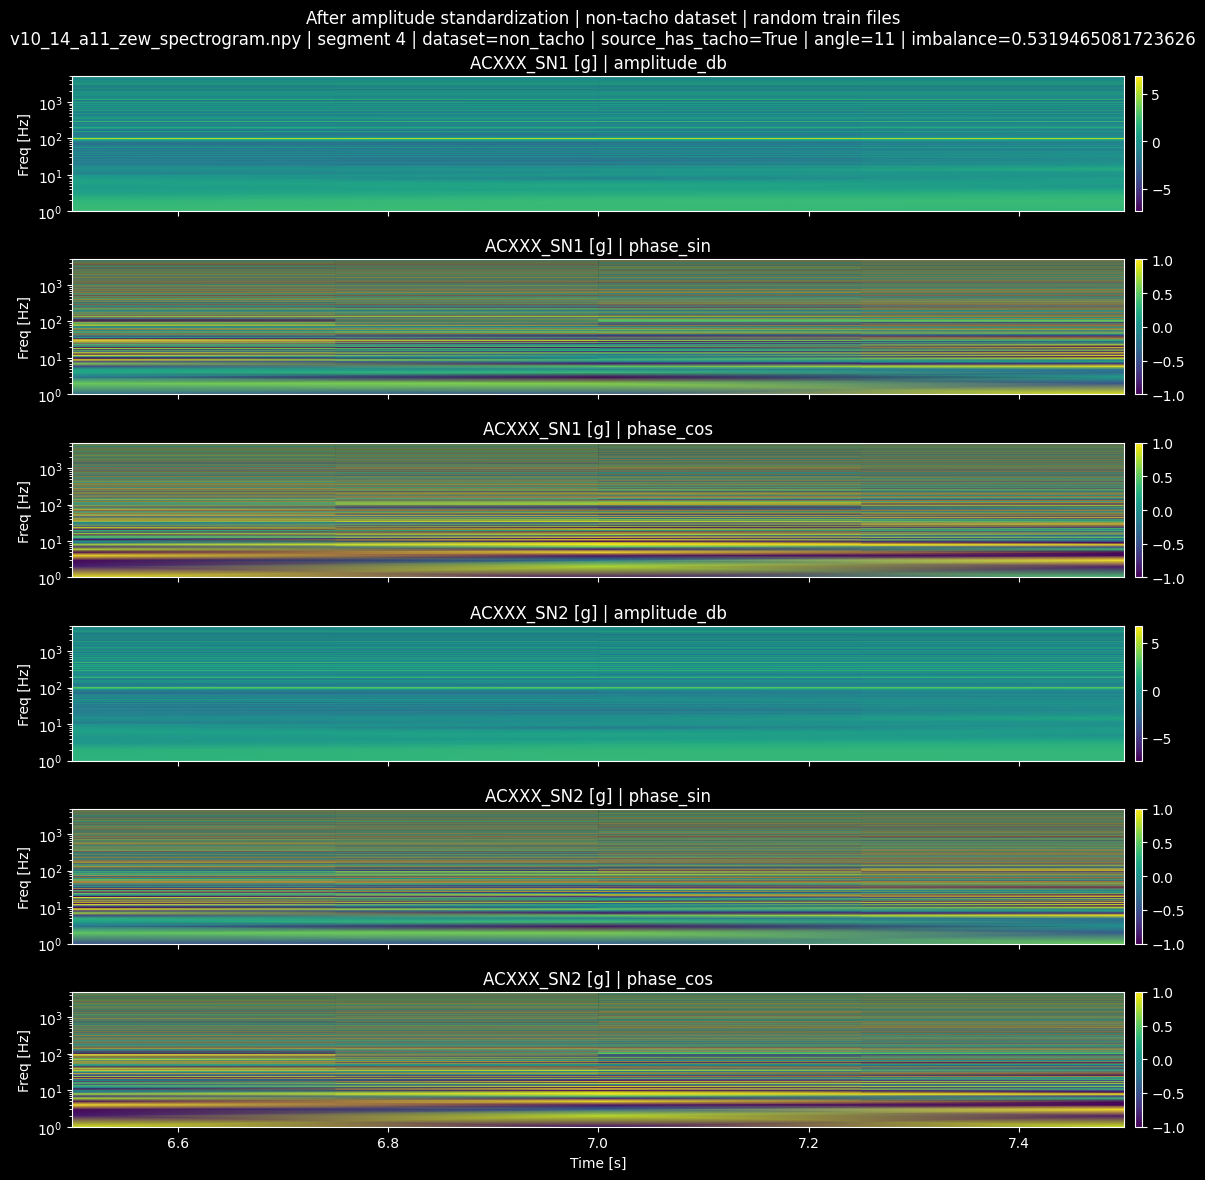

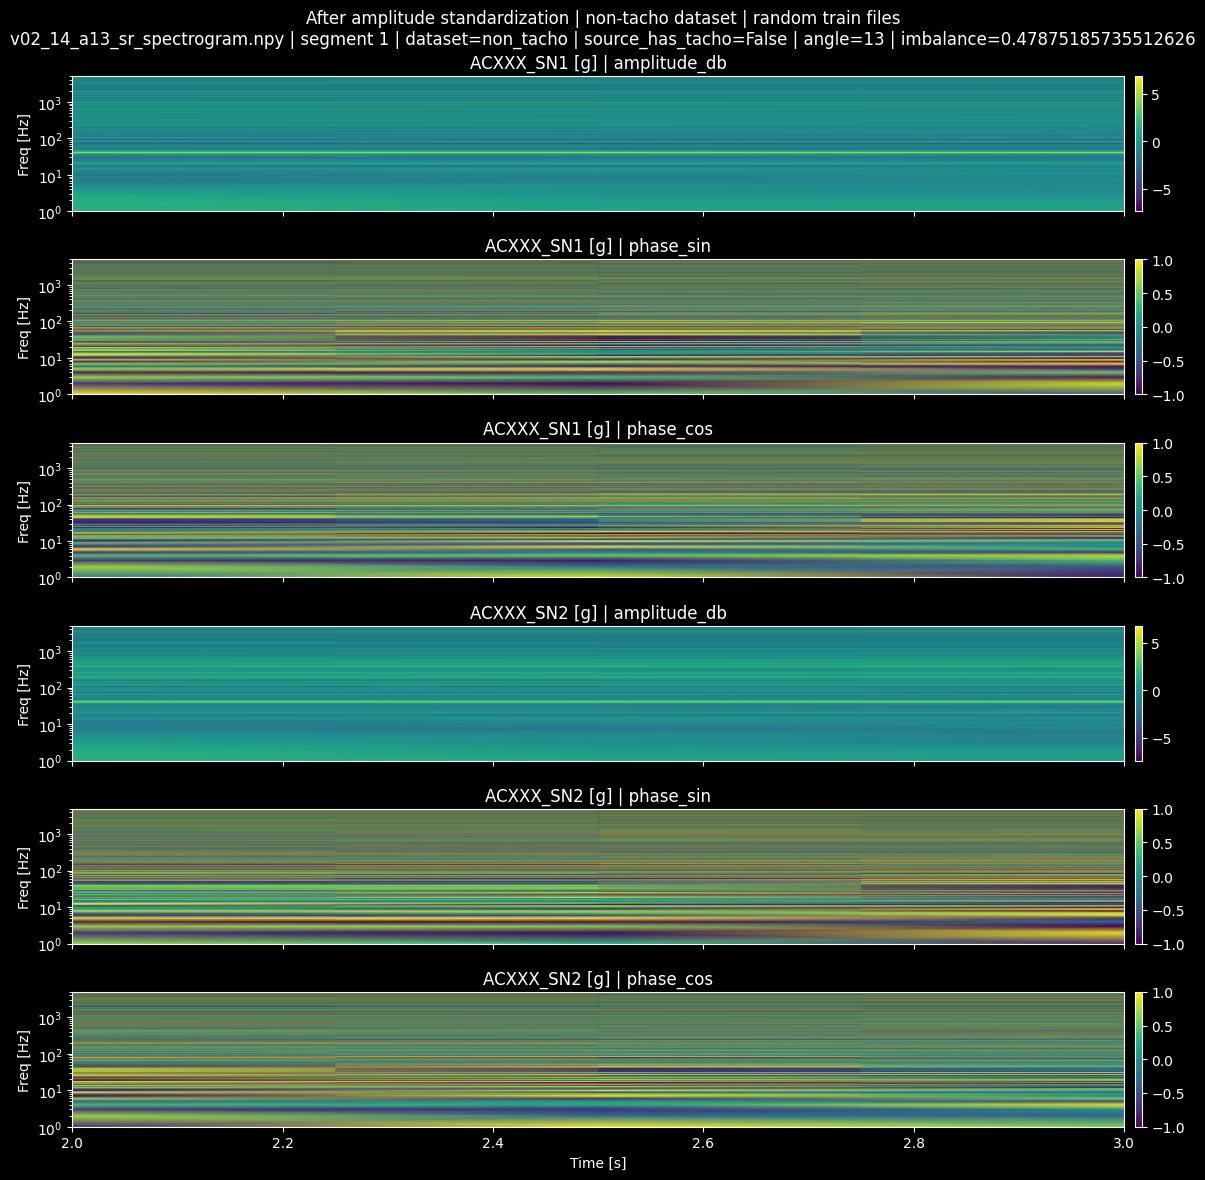

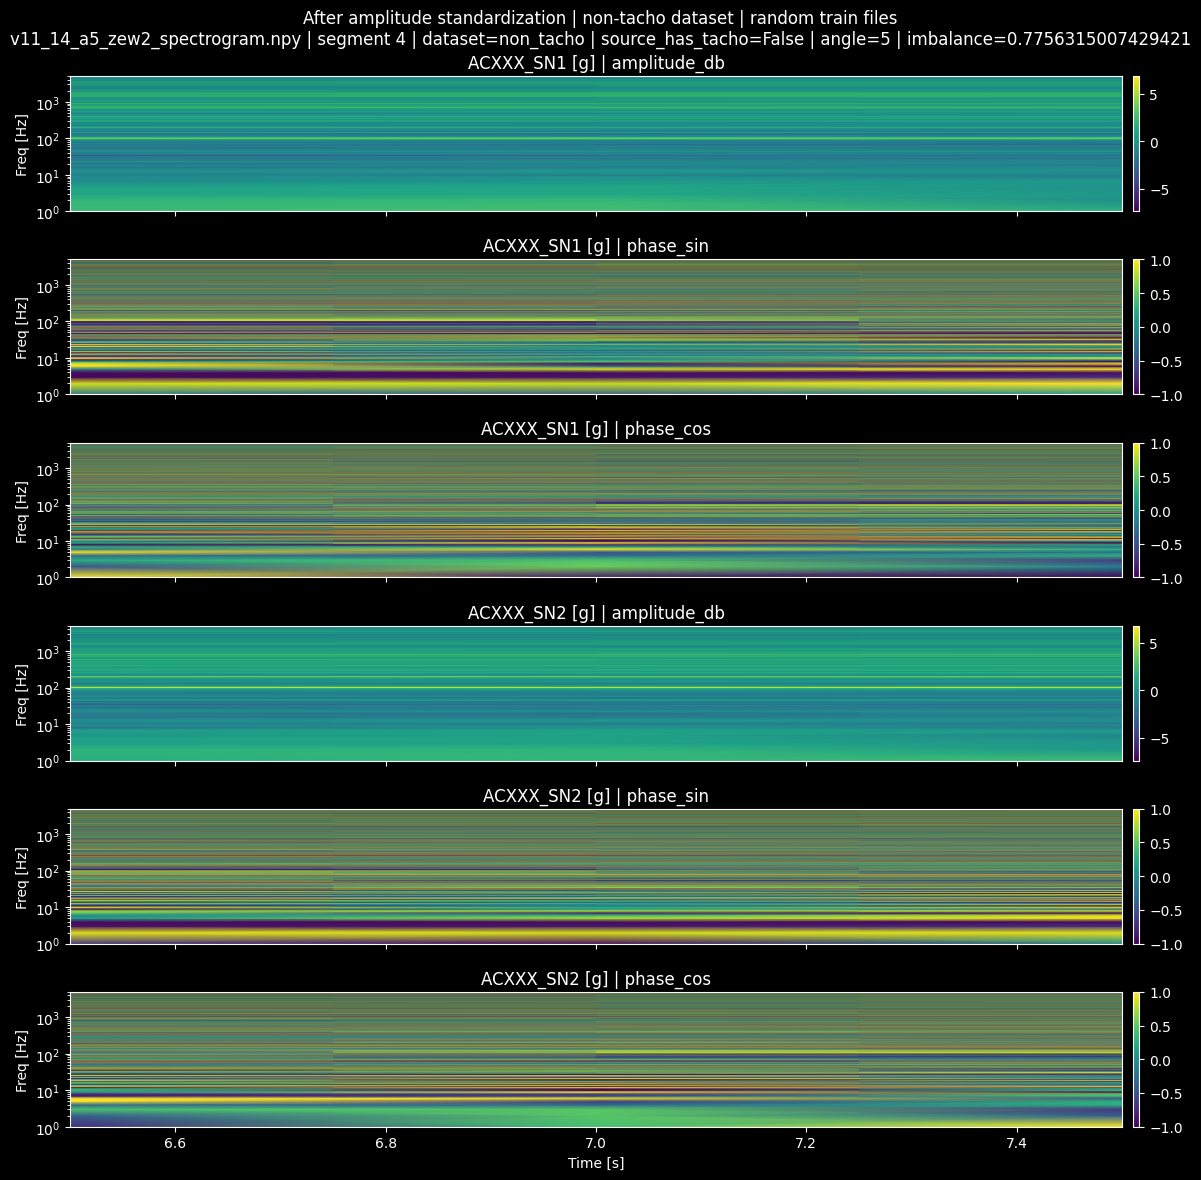

In [12]:
def compute_amplitude_color_limits(dataset):
    if not dataset:
        return None

    amplitude_components = [
        "ACXXX_SN1 [g] | amplitude_db",
        "ACXXX_SN2 [g] | amplitude_db",
    ]

    mins = []
    maxs = []

    for dp in dataset:
        name_to_idx = {name: i for i, name in enumerate(dp["component_names"])}

        for component in amplitude_components:
            if component not in name_to_idx:
                continue

            arr = dp["X"][name_to_idx[component]]
            mins.append(float(np.nanmin(arr)))
            maxs.append(float(np.nanmax(arr)))

    if not mins:
        return None

    return (min(mins), max(maxs))


def plot_datapoint_channels(dp, frequency_hz, title, amplitude_limits=None):
    X = dp["X"]
    time_s = dp["time_s"]
    names = dp["component_names"]

    n_channels = X.shape[0]

    fig, axes = plt.subplots(
        n_channels,
        1,
        figsize=(12, max(3, 2.0 * n_channels)),
        sharex=True,
        squeeze=False,
    )

    for i in range(n_channels):
        ax = axes[i, 0]
        name = names[i]

        kwargs = {}

        if amplitude_limits is not None and name.endswith("| amplitude_db") and name.startswith("ACXXX_SN"):
            kwargs["vmin"], kwargs["vmax"] = amplitude_limits

        if name.endswith("phase_sin") or name.endswith("phase_cos"):
            kwargs["vmin"], kwargs["vmax"] = -1.0, 1.0

        im = ax.pcolormesh(time_s, frequency_hz, X[i], shading="gouraud", **kwargs)
        ax.set_yscale("log")
        ax.set_ylabel("Freq [Hz]")
        ax.set_title(name)
        fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01)

    axes[-1, 0].set_xlabel("Time [s]")
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


def plot_random_source_files_examples(dataset, frequency_hz, title, n_files=3, seed=RANDOM_SEED, amplitude_limits=None):
    if not dataset:
        print(f"No examples to plot for: {title}")
        return

    rng = np.random.default_rng(seed)

    by_source = {}

    for dp in dataset:
        source = dp["metadata"]["source_npy"]
        by_source.setdefault(source, []).append(dp)

    sources = sorted(by_source.keys())
    n_files = min(n_files, len(sources))

    chosen_sources = rng.choice(sources, size=n_files, replace=False)

    for source in chosen_sources:
        examples = by_source[source]
        dp = examples[int(rng.integers(0, len(examples)))]
        meta = dp["metadata"]

        plot_title = (
            f"{title}\n"
            f"{meta['source_npy']} | segment {meta['segment_idx']} | "
            f"dataset={meta['dataset_kind']} | source_has_tacho={meta['source_has_tacho']} | "
            f"angle={dp['y_angle_label']} | imbalance={dp['y_imbalance_value']}"
        )

        plot_datapoint_channels(dp, frequency_hz, plot_title, amplitude_limits=amplitude_limits)


amplitude_plot_limits = compute_amplitude_color_limits(
    norm_train_tacho + norm_train_non_tacho
)

print("Amplitude color limits:", amplitude_plot_limits)

plot_random_source_files_examples(
    norm_train_tacho,
    frequency_hz_common,
    title="After amplitude standardization | tacho dataset | random train files",
    n_files=3,
    amplitude_limits=amplitude_plot_limits,
)

plot_random_source_files_examples(
    norm_train_non_tacho,
    frequency_hz_common,
    title="After amplitude standardization | non-tacho dataset | random train files",
    n_files=3,
    amplitude_limits=amplitude_plot_limits,
)


In [13]:
def stats_to_jsonable(stats):
    if stats is None:
        return None

    return {
        "mode": stats["mode"],
        "fitted_on": stats.get("fitted_on", "raw_train_split"),
        "normalized_component_indices": [int(i) for i in stats["normalized_component_indices"]],
        "normalized_component_names": stats["normalized_component_names"],
        "unchanged_component_indices": [int(i) for i in stats["unchanged_component_indices"]],
        "unchanged_component_names": stats["unchanged_component_names"],
        "all_component_names": stats["all_component_names"],
        "mean": stats["mean"].astype(float).tolist(),
        "std": stats["std"].astype(float).tolist(),
    }


tacho_normalized_bundle = {
    "train": norm_train_tacho,
    "test": norm_test_tacho,
    "frequency_hz": frequency_hz_common,
    "component_names": component_names_tacho,
    "location_to_imbalance": LOCATION_TO_IMBALANCE,
    "standardization": stats_tacho,
    "dataset_kind": "tacho",
    "normalization": "sensor_amplitude_standardization_only_sincos_unchanged",
    "amplitude_plot_limits": amplitude_plot_limits,
    "phase_representation": "sin_cos",
    "angle_divisions": ANGLE_DIVISIONS,
}

non_tacho_normalized_bundle = {
    "train": norm_train_non_tacho,
    "test": norm_test_non_tacho,
    "frequency_hz": frequency_hz_common,
    "component_names": component_names_non_tacho,
    "location_to_imbalance": LOCATION_TO_IMBALANCE,
    "standardization": stats_non_tacho,
    "dataset_kind": "non_tacho",
    "normalization": "sensor_amplitude_standardization_only_sincos_unchanged",
    "amplitude_plot_limits": amplitude_plot_limits,
    "phase_representation": "sin_cos",
    "angle_divisions": ANGLE_DIVISIONS,
}

np.save(
    NORMALIZED_DIR / "dataset_tacho_normalized.npy",
    tacho_normalized_bundle,
    allow_pickle=True,
)

np.save(
    NORMALIZED_DIR / "dataset_non_tacho_normalized.npy",
    non_tacho_normalized_bundle,
    allow_pickle=True,
)

normalization_info = {
    "normalization": "sensor_amplitude_standardization_only",
    "note": "Only SN1/SN2 amplitude_db components are standardized. phase_sin, phase_cos, and tachometer components are copied unchanged.",
    "phase_representation": "sin_cos",
    "angle_divisions": ANGLE_DIVISIONS,
    "angle_rule": "angle_rad = 2*pi*angle_label/17",
    "baseline_rule": "vXX_14_processed files are angle=0 and imbalance=0",
    "amplitude_plot_limits": amplitude_plot_limits,
    "tacho": stats_to_jsonable(stats_tacho),
    "non_tacho": stats_to_jsonable(stats_non_tacho),
    "location_to_imbalance": LOCATION_TO_IMBALANCE,
    "train_ratio": TRAIN_RATIO,
    "random_seed": RANDOM_SEED,
    "segments_per_sample": SEGMENTS_PER_SAMPLE,
}

with open(NORMALIZED_DIR / "normalization_info.json", "w", encoding="utf-8") as f:
    json.dump(normalization_info, f, indent=2, ensure_ascii=False)

with open(NORMALIZED_DIR / "location_to_imbalance.json", "w", encoding="utf-8") as f:
    json.dump(LOCATION_TO_IMBALANCE, f, indent=2, ensure_ascii=False)

print(f"Saved normalized bundle datasets to: {NORMALIZED_DIR}")


Saved normalized bundle datasets to: D:\Projects\GitHub\Wywazanie\Pipeline\Dataset_Normalzied


In [14]:
def clear_export_folders():
    export_folders = [
        NORMALIZED_EXPORT_DIR / "tacho" / "train",
        NORMALIZED_EXPORT_DIR / "tacho" / "test",
        NORMALIZED_EXPORT_DIR / "non_tacho" / "train",
        NORMALIZED_EXPORT_DIR / "non_tacho" / "test",
    ]

    for folder in export_folders:
        if folder.exists():
            shutil.rmtree(folder)

        folder.mkdir(parents=True, exist_ok=True)

    old_manifest = NORMALIZED_EXPORT_DIR / "individual_datapoints_manifest.csv"

    if old_manifest.exists():
        old_manifest.unlink()


def clean_token(value, unknown="unknown"):
    if value is None:
        return unknown

    text = str(value).strip()

    for old in [" ", "/", "\\", ":", ";", ","]:
        text = text.replace(old, "_")

    return text if text else unknown


def format_two_digit(value, unknown="unknown"):
    if value is None:
        return unknown

    try:
        return f"{int(float(value)):02d}"
    except (TypeError, ValueError):
        return clean_token(value, unknown=unknown)


def velocity_string_from_metadata(metadata):
    v_main = metadata.get("v_main", None)
    v_sub = metadata.get("v_sub", None)

    if v_main is not None and v_sub is not None:
        return f"{int(v_main):02d}_{int(v_sub):02d}"

    if v_main is not None:
        return f"{int(v_main):02d}"

    return "unknown"


def datapoint_filename(dp, index):
    metadata = dp["metadata"]

    angle = format_two_digit(dp["y_angle_label"])
    velocity = velocity_string_from_metadata(metadata)
    imbalance = format_two_digit(dp["y_imbalance_value"])
    segment = format_two_digit(metadata.get("segment_idx", None))
    index_str = f"{int(index):06d}"

    return (
        f"Angle_{angle}"
        f"_Velocity_{velocity}"
        f"_Imbalance_{imbalance}"
        f"_Segment_{segment}"
        f"_Index_{index_str}.npy"
    )


def save_individual_datapoints(dataset, frequency_hz, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    rows = []

    for idx, dp in enumerate(dataset):
        filename = datapoint_filename(dp, idx)
        out_path = out_dir / filename

        payload = {
            "X": dp["X"].astype(np.float32),
            "y_imbalance_value": float(dp["y_imbalance_value"]),
            "y_angle_label": int(dp["y_angle_label"]),
            "y_angle_rad": float(dp["y_angle_rad"]),
            "y_angle_sin_cos": dp["y_angle_sin_cos"].astype(np.float32),
            "y_actual_amp": float(dp["y_actual_amp"]),
            "y_actual_phase_rad": float(dp["y_actual_phase_rad"]),
            "y_actual_phase_sin_cos": dp["y_actual_phase_sin_cos"].astype(np.float32),
            "metadata": dp["metadata"],
            "component_names": dp["component_names"],
            "frequency_hz": frequency_hz.astype(np.float32),
            "time_s": dp["time_s"].astype(np.float32),
            "phase_representation": "sin_cos",
        }

        np.save(out_path, payload, allow_pickle=True)

        rows.append({
            "path": str(out_path),
            "filename": filename,
            "dataset_kind": dp["metadata"].get("dataset_kind", None),
            "split": out_dir.name,
            "angle_label": dp["y_angle_label"],
            "angle_rad": dp["y_angle_rad"],
            "angle_sin": float(dp["y_angle_sin_cos"][0]),
            "angle_cos": float(dp["y_angle_sin_cos"][1]),
            "actual_amp": float(dp["y_actual_amp"]),
            "actual_phase_rad": float(dp["y_actual_phase_rad"]),
            "velocity": velocity_string_from_metadata(dp["metadata"]),
            "imbalance": dp["y_imbalance_value"],
            "location": dp["metadata"].get("location", None),
            "segment_idx": dp["metadata"].get("segment_idx", None),
            "source_npy": dp["metadata"].get("source_npy", None),
            "source_has_tacho": dp["metadata"].get("source_has_tacho", None),
            "X_shape": str(dp["X"].shape),
        })

    return rows


if CLEAR_EXPORTED_DATASETS:
    clear_export_folders()

export_manifest_rows = []

export_specs = [
    ("tacho", "train", norm_train_tacho),
    ("tacho", "test", norm_test_tacho),
    ("non_tacho", "train", norm_train_non_tacho),
    ("non_tacho", "test", norm_test_non_tacho),
]

for dataset_kind, split, dataset in export_specs:
    out_dir = NORMALIZED_EXPORT_DIR / dataset_kind / split

    rows = save_individual_datapoints(
        dataset=dataset,
        frequency_hz=frequency_hz_common,
        out_dir=out_dir,
    )

    export_manifest_rows.extend(rows)

    print(f"Saved {len(rows):6d} files to: {out_dir}")

export_manifest = pd.DataFrame(export_manifest_rows)
export_manifest_path = NORMALIZED_EXPORT_DIR / "individual_datapoints_manifest.csv"
export_manifest.to_csv(export_manifest_path, index=False)

print()
print(f"Saved export manifest to: {export_manifest_path}")
display(export_manifest.head())

print("Exported split counts:")
display(export_manifest.groupby(["dataset_kind", "split"]).size())


Saved    703 files to: D:\Projects\GitHub\Wywazanie\Pipeline\Dataset_Normalzied\tacho\train
Saved    179 files to: D:\Projects\GitHub\Wywazanie\Pipeline\Dataset_Normalzied\tacho\test
Saved   1803 files to: D:\Projects\GitHub\Wywazanie\Pipeline\Dataset_Normalzied\non_tacho\train
Saved    451 files to: D:\Projects\GitHub\Wywazanie\Pipeline\Dataset_Normalzied\non_tacho\test

Saved export manifest to: D:\Projects\GitHub\Wywazanie\Pipeline\Dataset_Normalzied\individual_datapoints_manifest.csv


,path,filename,dataset_kind,split,angle_label,angle_rad,angle_sin,angle_cos,actual_amp,actual_phase_rad,velocity,imbalance,location,segment_idx,source_npy,source_has_tacho,X_shape
0,D:\Projects\GitHub\Wywazanie\Pipeline\Dataset_...,Angle_13_Velocity_03_14_Imbalance_00_Segment_0...,tacho,train,13,4.804789,-0.995734,0.092268,0.002405,-1.784435,03_14,0.531947,zew,3,v03_14_a13_zew_spectrogram.npy,True,"(9, 5000, 3)"
1,D:\Projects\GitHub\Wywazanie\Pipeline\Dataset_...,Angle_07_Velocity_08_14_Imbalance_00_Segment_0...,tacho,train,7,2.587194,0.526432,-0.850217,0.001353,-1.483533,08_14,0.531947,zew,3,v08_14_a7_zew_spectrogram.npy,True,"(9, 5000, 3)"
2,D:\Projects\GitHub\Wywazanie\Pipeline\Dataset_...,Angle_13_Velocity_04_14_Imbalance_00_Segment_0...,tacho,train,13,4.804789,-0.995734,0.092268,0.000322,0.354951,04_14,0.531947,zew,1,v04_14_a13_zew_spectrogram.npy,True,"(9, 5000, 3)"
3,D:\Projects\GitHub\Wywazanie\Pipeline\Dataset_...,Angle_11_Velocity_01_14_Imbalance_00_Segment_0...,tacho,train,11,4.065590,-0.798017,-0.602635,0.000484,-0.566184,01_14,0.531947,zew,0,v01_14_a11_zew_spectrogram.npy,True,"(9, 5000, 3)"
4,D:\Projects\GitHub\Wywazanie\Pipeline\Dataset_...,Angle_03_Velocity_09_14_Imbalance_00_Segment_0...,tacho,train,3,1.108797,0.895163,0.445738,0.001060,-0.324361,09_14,0.531947,zew,3,v09_14_a3_zew_spectrogram.npy,True,"(9, 5000, 3)"


Exported split counts:


dataset_kind  split
non_tacho     test      451
              train    1803
tacho         test      179
              train     703
dtype: int64

In [15]:
import numpy as np
from pathlib import Path

# Ścieżka do folderu z wyeksportowanymi danymi
train_dir = Path(r"D:\Projects\GitHub\Wywazanie\Pipeline\Dataset_Normalzied\tacho\train")
sample_file = list(train_dir.glob("*.npy"))[0]

payload = np.load(sample_file, allow_pickle=True).item()
print("Klucze zapisane w pliku NPY:")
for key in payload.keys():
    print(f"- {key}")


Klucze zapisane w pliku NPY:
- X
- y_imbalance_value
- y_angle_label
- y_angle_rad
- y_angle_sin_cos
- y_actual_amp
- y_actual_phase_rad
- y_actual_phase_sin_cos
- metadata
- component_names
- frequency_hz
- time_s
- phase_representation
